# Pandas for AI Engineers - Comprehensive Guide

**Advanced Analytics using Statistics - PG-DBDA**

This notebook covers all essential Pandas concepts required for AI/ML engineering and data analytics.

## Table of Contents

### Phase 1: Fundamentals
1. Introduction & Setup
2. Creating Sample Dataset
3. Series - The 1D Data Structure
4. DataFrame Basics - The 2D Data Structure
5. Data Inspection & Exploration

### Phase 2: Data Manipulation
6. Data Selection & Filtering
7. Handling Missing Data
8. Data Cleaning & Transformation
9. Merging, Joining & Concatenation
10. GroupBy & Aggregation

### Phase 3: Advanced Analytics
11. Time Series Analysis
12. Pivot Tables & Cross-tabulation
13. Statistical Operations
14. Data Visualization Integration
15. Real-World Analytics Projects
16. Best Practices & Performance

# PHASE 1: FUNDAMENTALS

---

## 1. Introduction & Setup

Pandas is the essential library for data manipulation and analysis in Python.

**Why Pandas for AI/ML?**
- Built on NumPy (fast numerical operations)
- Handles structured/tabular data efficiently
- Powerful data cleaning and transformation
- Seamless integration with scikit-learn, matplotlib, seaborn
- Essential for ETL (Extract, Transform, Load) operations
- Foundation for exploratory data analysis (EDA)

**Key Data Structures:**
- **Series**: 1D labeled array (like a column)
- **DataFrame**: 2D labeled table (like Excel/SQL table)

In [62]:
# Import required libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")
print("Libraries imported successfully!")

Pandas Version: 2.3.3
NumPy Version: 2.3.4
Libraries imported successfully!


## 2. Creating Sample Dataset

First, let's create a comprehensive sales dataset that we'll use throughout this notebook.

In [63]:
# Create a comprehensive sales dataset
np.random.seed(42)

# Generate dates
dates = pd.date_range('2023-01-01', '2024-12-31', freq='D')
n_records = 1000

# Generate data
data = {
    'Order_ID': [f'ORD{str(i).zfill(5)}' for i in range(1, n_records + 1)],
    'Date': np.random.choice(dates, n_records),
    'Customer_ID': np.random.randint(1000, 2000, n_records),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Headphones', 'Monitor', 'Keyboard', 'Mouse'], n_records),
    'Category': np.random.choice(['Electronics', 'Accessories', 'Computers'], n_records),
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'Central'], n_records),
    'Salesperson': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank'], n_records),
    'Quantity': np.random.randint(1, 10, n_records),
    'Unit_Price': np.random.uniform(10, 1000, n_records).round(2),
    'Discount': np.random.choice([0, 5, 10, 15, 20, 25], n_records),
    'Payment_Method': np.random.choice(['Credit Card', 'Debit Card', 'Cash', 'UPI', 'Net Banking'], n_records),
    'Customer_Age': np.random.randint(18, 70, n_records),
    'Customer_Gender': np.random.choice(['M', 'F', 'Other'], n_records),
}

# Calculate derived columns
df_sales = pd.DataFrame(data)
df_sales['Total_Price'] = df_sales['Quantity'] * df_sales['Unit_Price']
df_sales['Discount_Amount'] = (df_sales['Total_Price'] * df_sales['Discount'] / 100).round(2)
df_sales['Final_Amount'] = (df_sales['Total_Price'] - df_sales['Discount_Amount']).round(2)

# Add some missing values intentionally (for practice)
missing_indices = np.random.choice(df_sales.index, size=50, replace=False)
df_sales.loc[missing_indices[:20], 'Customer_Age'] = np.nan
df_sales.loc[missing_indices[20:35], 'Discount'] = np.nan
df_sales.loc[missing_indices[35:50], 'Region'] = np.nan

# Sort by date
df_sales = df_sales.sort_values('Date').reset_index(drop=True)

print(f"Dataset created with {len(df_sales)} records")
print(f"Columns: {list(df_sales.columns)}")

Dataset created with 1000 records
Columns: ['Order_ID', 'Date', 'Customer_ID', 'Product', 'Category', 'Region', 'Salesperson', 'Quantity', 'Unit_Price', 'Discount', 'Payment_Method', 'Customer_Age', 'Customer_Gender', 'Total_Price', 'Discount_Amount', 'Final_Amount']


In [64]:
# Save to Excel file in the data folder
import os

# Create data directory if it doesn't exist
data_dir = '/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats/data'
os.makedirs(data_dir, exist_ok=True)

# Save to Excel with multiple sheets
file_path = os.path.join(data_dir, 'sales_data.xlsx')

with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    df_sales.to_excel(writer, sheet_name='Sales', index=False)
    
    # Create additional sheets for practice
    # Product catalog
    product_catalog = pd.DataFrame({
        'Product': ['Laptop', 'Phone', 'Tablet', 'Headphones', 'Monitor', 'Keyboard', 'Mouse'],
        'Category': ['Computers', 'Electronics', 'Electronics', 'Accessories', 'Computers', 'Accessories', 'Accessories'],
        'Brand': ['Dell', 'Samsung', 'Apple', 'Sony', 'LG', 'Logitech', 'Logitech'],
        'Stock': [50, 200, 100, 300, 75, 150, 250],
        'Supplier': ['Supplier A', 'Supplier B', 'Supplier C', 'Supplier D', 'Supplier A', 'Supplier E', 'Supplier E']
    })
    product_catalog.to_excel(writer, sheet_name='Products', index=False)
    
    # Customer demographics
    customer_demo = pd.DataFrame({
        'Customer_ID': range(1000, 2000),
        'City': np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Pune', 'Hyderabad'], 1000),
        'Loyalty_Status': np.random.choice(['Bronze', 'Silver', 'Gold', 'Platinum'], 1000),
        'Registration_Date': pd.date_range('2020-01-01', periods=1000, freq='D')
    })
    customer_demo.to_excel(writer, sheet_name='Customers', index=False)

print(f"✅ Dataset saved successfully to: {file_path}")
print(f"   - Sales sheet: {len(df_sales)} records")
print(f"   - Products sheet: {len(product_catalog)} records")
print(f"   - Customers sheet: {len(customer_demo)} records")

✅ Dataset saved successfully to: /Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats/data/sales_data.xlsx
   - Sales sheet: 1000 records
   - Products sheet: 7 records
   - Customers sheet: 1000 records


## 3. Series - The 1D Data Structure

A Series is a one-dimensional labeled array that can hold any data type.

### 3.1 Creating Series

In [65]:
# Method 1: From list
sales_list = [100, 200, 150, 300, 250]
series_from_list = pd.Series(sales_list)
print("Series from list:")
print(series_from_list)
print(f"Type: {type(series_from_list)}")
print()

# Method 2: From list with custom index
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
series_with_index = pd.Series(sales_list, index=months)
print("Series with custom index:")
print(series_with_index)
print()

# Method 3: From dictionary
sales_dict = {'Jan': 100, 'Feb': 200, 'Mar': 150, 'Apr': 300, 'May': 250}
series_from_dict = pd.Series(sales_dict)
print("Series from dictionary:")
print(series_from_dict)
print()

# Method 4: From NumPy array
np_array = np.array([10, 20, 30, 40, 50])
series_from_numpy = pd.Series(np_array, index=['A', 'B', 'C', 'D', 'E'])
print("Series from NumPy array:")
print(series_from_numpy)
print()

# Method 5: From scalar value
series_scalar = pd.Series(100, index=['A', 'B', 'C'])
print("Series from scalar:")
print(series_scalar)

Series from list:
0    100
1    200
2    150
3    300
4    250
dtype: int64
Type: <class 'pandas.core.series.Series'>

Series with custom index:
Jan    100
Feb    200
Mar    150
Apr    300
May    250
dtype: int64

Series from dictionary:
Jan    100
Feb    200
Mar    150
Apr    300
May    250
dtype: int64

Series from NumPy array:
A    10
B    20
C    30
D    40
E    50
dtype: int64

Series from scalar:
A    100
B    100
C    100
dtype: int64


### 3.2 Series Attributes & Methods

In [66]:
# Use the series we created
s = series_with_index

print("=== Series Attributes ===")
print(f"Values: {s.values}")
print(f"Index: {s.index}")
print(f"Data type: {s.dtype}")
print(f"Shape: {s.shape}")
print(f"Size: {s.size}")
print(f"Name: {s.name}")
print()

# Set name
s.name = "Monthly Sales"
print(f"After setting name: {s.name}")
print()

print("=== Basic Statistics ===")
print(f"Sum: {s.sum()}")
print(f"Mean: {s.mean():.2f}")
print(f"Median: {s.median()}")
print(f"Std Dev: {s.std():.2f}")
print(f"Min: {s.min()}")
print(f"Max: {s.max()}")
print(f"Count: {s.count()}")
print()

# Describe - comprehensive statistics
print("Describe:")
print(s.describe())

=== Series Attributes ===
Values: [100 200 150 300 250]
Index: Index(['Jan', 'Feb', 'Mar', 'Apr', 'May'], dtype='object')
Data type: int64
Shape: (5,)
Size: 5
Name: None

After setting name: Monthly Sales

=== Basic Statistics ===
Sum: 1000
Mean: 200.00
Median: 200.0
Std Dev: 79.06
Min: 100
Max: 300
Count: 5

Describe:
count      5.00
mean     200.00
std       79.06
min      100.00
25%      150.00
50%      200.00
75%      250.00
max      300.00
Name: Monthly Sales, dtype: float64


### 3.3 Indexing & Slicing Series

In [67]:
s = pd.Series([10, 20, 30, 40, 50], index=['A', 'B', 'C', 'D', 'E'])
print("Original Series:")
print(s)
print()

# Position-based indexing with iloc
print("=== iloc (position-based) ===")
print(f"First element s.iloc[0]: {s.iloc[0]}")
print(f"Last element s.iloc[-1]: {s.iloc[-1]}")
print(f"Slice s.iloc[1:4]:\n{s.iloc[1:4]}")
print(f"Multiple positions s.iloc[[0, 2, 4]]:\n{s.iloc[[0, 2, 4]]}")
print()

# Label-based indexing with loc
print("=== loc (label-based) ===")
print(f"Element at 'C': {s.loc['C']}")
print(f"Slice s.loc['B':'D']:\n{s.loc['B':'D']}")  # Note: inclusive on both ends!
print(f"Multiple labels s.loc[['A', 'C', 'E']]:\n{s.loc[['A', 'C', 'E']]}")
print()

# Boolean indexing
print("=== Boolean Indexing ===")
mask = s > 25
print(f"Mask (s > 25):\n{mask}")
print(f"Values > 25:\n{s[mask]}")
print(f"Values between 20 and 40:\n{s[(s >= 20) & (s <= 40)]}")
print()

# Direct indexing (works like loc for labels)
print("=== Direct Indexing ===")
print(f"s['B']: {s['B']}")
print(f"s[['A', 'D']]:\n{s[['A', 'D']]}")

Original Series:
A    10
B    20
C    30
D    40
E    50
dtype: int64

=== iloc (position-based) ===
First element s.iloc[0]: 10
Last element s.iloc[-1]: 50
Slice s.iloc[1:4]:
B    20
C    30
D    40
dtype: int64
Multiple positions s.iloc[[0, 2, 4]]:
A    10
C    30
E    50
dtype: int64

=== loc (label-based) ===
Element at 'C': 30
Slice s.loc['B':'D']:
B    20
C    30
D    40
dtype: int64
Multiple labels s.loc[['A', 'C', 'E']]:
A    10
C    30
E    50
dtype: int64

=== Boolean Indexing ===
Mask (s > 25):
A    False
B    False
C     True
D     True
E     True
dtype: bool
Values > 25:
C    30
D    40
E    50
dtype: int64
Values between 20 and 40:
B    20
C    30
D    40
dtype: int64

=== Direct Indexing ===
s['B']: 20
s[['A', 'D']]:
A    10
D    40
dtype: int64


### 3.4 Series Operations

In [68]:
# Arithmetic operations (vectorized)
s1 = pd.Series([1, 2, 3, 4, 5], index=['A', 'B', 'C', 'D', 'E'])
s2 = pd.Series([10, 20, 30, 40, 50], index=['A', 'B', 'C', 'D', 'E'])

print("s1:", s1.values)
print("s2:", s2.values)
print()

print("Addition:", (s1 + s2).values)
print("Subtraction:", (s2 - s1).values)
print("Multiplication:", (s1 * s2).values)
print("Division:", (s2 / s1).values)
print("Power:", (s1 ** 2).values)
print()

# Operations with misaligned indexes
s3 = pd.Series([100, 200], index=['A', 'F'])
print("s1 + s3 (misaligned):")
print(s1 + s3)  # NaN where index doesn't match
print()

# Updating values
s = pd.Series([10, 20, 30], index=['A', 'B', 'C'])
print("Original:", s.values)

s.loc['B'] = 99
print("After s.loc['B'] = 99:", s.values)

s.iloc[0] = 77
print("After s.iloc[0] = 77:", s.values)
print()

# Adding new elements
s.loc['D'] = 40
print("After adding 'D':")
print(s)
print()

# Dropping elements
s_dropped = s.drop('B')
print("After dropping 'B':")
print(s_dropped)
print("\nOriginal s (unchanged):")
print(s)

s1: [1 2 3 4 5]
s2: [10 20 30 40 50]

Addition: [11 22 33 44 55]
Subtraction: [ 9 18 27 36 45]
Multiplication: [ 10  40  90 160 250]
Division: [10. 10. 10. 10. 10.]
Power: [ 1  4  9 16 25]

s1 + s3 (misaligned):
A    101.0
B      NaN
C      NaN
D      NaN
E      NaN
F      NaN
dtype: float64

Original: [10 20 30]
After s.loc['B'] = 99: [10 99 30]
After s.iloc[0] = 77: [77 99 30]

After adding 'D':
A    77
B    99
C    30
D    40
dtype: int64

After dropping 'B':
A    77
C    30
D    40
dtype: int64

Original s (unchanged):
A    77
B    99
C    30
D    40
dtype: int64


## 4. DataFrame Basics - The 2D Data Structure

DataFrame is a 2D labeled data structure with columns of potentially different types.

### 4.1 Creating DataFrames

In [69]:
# Method 1: From dictionary of lists
data_dict = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Age': [25, 30, 35, 28],
    'City': ['Mumbai', 'Delhi', 'Bangalore', 'Chennai'],
    'Salary': [50000, 60000, 75000, 55000]
}
df1 = pd.DataFrame(data_dict)
print("DataFrame from dictionary:")
print(df1)
print()

# Method 2: From list of lists
data_list = [
    ['Alice', 25, 'Mumbai', 50000],
    ['Bob', 30, 'Delhi', 60000],
    ['Charlie', 35, 'Bangalore', 75000],
    ['Diana', 28, 'Chennai', 55000]
]
df2 = pd.DataFrame(data_list, columns=['Name', 'Age', 'City', 'Salary'])
print("DataFrame from list of lists:")
print(df2)
print()

# Method 3: From list of dictionaries
data_list_dict = [
    {'Name': 'Alice', 'Age': 25, 'City': 'Mumbai'},
    {'Name': 'Bob', 'Age': 30, 'City': 'Delhi'},
    {'Name': 'Charlie', 'Age': 35, 'City': 'Bangalore'}
]
df3 = pd.DataFrame(data_list_dict)
print("DataFrame from list of dictionaries:")
print(df3)
print()

# Method 4: From NumPy array
np_data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
df4 = pd.DataFrame(np_data, columns=['A', 'B', 'C'], index=['Row1', 'Row2', 'Row3'])
print("DataFrame from NumPy array:")
print(df4)
print()

# Method 5: From Series
s1 = pd.Series([10, 20, 30], name='Col1')
s2 = pd.Series([40, 50, 60], name='Col2')
df5 = pd.DataFrame({'Col1': s1, 'Col2': s2})
print("DataFrame from Series:")
print(df5)

DataFrame from dictionary:
      Name  Age       City  Salary
0    Alice   25     Mumbai   50000
1      Bob   30      Delhi   60000
2  Charlie   35  Bangalore   75000
3    Diana   28    Chennai   55000

DataFrame from list of lists:
      Name  Age       City  Salary
0    Alice   25     Mumbai   50000
1      Bob   30      Delhi   60000
2  Charlie   35  Bangalore   75000
3    Diana   28    Chennai   55000

DataFrame from list of dictionaries:
      Name  Age       City
0    Alice   25     Mumbai
1      Bob   30      Delhi
2  Charlie   35  Bangalore

DataFrame from NumPy array:
      A  B  C
Row1  1  2  3
Row2  4  5  6
Row3  7  8  9

DataFrame from Series:
   Col1  Col2
0    10    40
1    20    50
2    30    60


### 4.2 Reading from Files

In [70]:
# Read Excel file we created earlier
data_path = '/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats/data/sales_data.xlsx'

# Read the Sales sheet
df = pd.read_excel(data_path, sheet_name='Sales', engine='openpyxl')
print(f"✅ Loaded Sales data: {df.shape[0]} rows, {df.shape[1]} columns")
print()

# Read Products sheet
df_products = pd.read_excel(data_path, sheet_name='Products', engine='openpyxl')
print(f"✅ Loaded Products data: {df_products.shape}")
print()

# Read Customers sheet
df_customers = pd.read_excel(data_path, sheet_name='Customers', engine='openpyxl')
print(f"✅ Loaded Customers data: {df_customers.shape}")
print()

# Read multiple sheets at once
all_sheets = pd.read_excel(data_path, sheet_name=None, engine='openpyxl')
print(f"Available sheets: {list(all_sheets.keys())}")

✅ Loaded Sales data: 1000 rows, 16 columns

✅ Loaded Products data: (7, 5)

✅ Loaded Customers data: (1000, 4)

Available sheets: ['Sales', 'Products', 'Customers']
✅ Loaded Products data: (7, 5)

✅ Loaded Customers data: (1000, 4)

Available sheets: ['Sales', 'Products', 'Customers']


## 5. Data Inspection & Exploration

Essential methods to understand your data before analysis.

In [71]:
# View first and last rows
print("=== First 5 rows (head) ===")
print(df.head())
print()

print("=== Last 5 rows (tail) ===")
print(df.tail())
print()

print("=== First 3 rows ===")
print(df.head(3))
print()

# Shape and size
print("=== Shape & Size ===")
print(f"Shape: {df.shape}")  # (rows, columns)
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Total elements: {df.size}")
print()

# Column names and index
print("=== Columns & Index ===")
print(f"Columns: {df.columns.tolist()}")
print(f"Index: {df.index}")
print()

# Data types
print("=== Data Types ===")
print(df.dtypes)
print()

# General information
print("=== DataFrame Info ===")
df.info()

=== First 5 rows (head) ===
   Order_ID       Date  Customer_ID     Product     Category   Region  \
0  ORD00649 2023-01-01         1396    Keyboard  Electronics     West   
1  ORD00756 2023-01-01         1773      Laptop  Electronics    North   
2  ORD00980 2023-01-01         1886      Laptop  Electronics     East   
3  ORD00213 2023-01-02         1201  Headphones  Accessories  Central   
4  ORD00069 2023-01-02         1664      Laptop  Accessories  Central   

  Salesperson  Quantity  Unit_Price  Discount Payment_Method  Customer_Age  \
0         Eve         9      281.92      20.0     Debit Card          21.0   
1     Charlie         8      275.46       5.0    Net Banking          22.0   
2         Eve         2      182.22       0.0    Net Banking          20.0   
3       Frank         3      283.99      10.0     Debit Card          39.0   
4         Eve         9      203.50      10.0    Net Banking          21.0   

  Customer_Gender  Total_Price  Discount_Amount  Final_Amount  


In [72]:
# Statistical summary
print("=== Statistical Summary (describe) ===")
print(df.describe())
print()

# Include all columns (not just numeric)
print("=== Summary of all columns ===")
print(df.describe(include='all'))
print()

# Value counts for categorical columns
print("=== Value Counts for 'Product' ===")
print(df['Product'].value_counts())
print()

print("=== Value Counts for 'Region' ===")
print(df['Region'].value_counts())
print()

# Unique values
print("=== Unique Values ===")
print(f"Unique Products: {df['Product'].nunique()}")
print(f"Unique Regions: {df['Region'].nunique()}")
print(f"Unique Salespeople: {df['Salesperson'].nunique()}")
print()

# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print()

print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Percentage missing: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

=== Statistical Summary (describe) ===
                                Date  Customer_ID  Quantity  Unit_Price  \
count                           1000      1000.00   1000.00     1000.00   
mean   2023-12-25 22:42:14.400000256      1500.19      5.02      504.39   
min              2023-01-01 00:00:00      1000.00      1.00       10.93   
25%              2023-06-16 18:00:00      1240.25      3.00      263.44   
50%              2023-12-31 00:00:00      1494.50      5.00      490.58   
75%              2024-07-01 00:00:00      1766.50      7.00      747.37   
max              2024-12-30 00:00:00      1997.00      9.00      999.36   
std                              NaN       298.45      2.54      286.13   

       Discount  Customer_Age  Total_Price  Discount_Amount  Final_Amount  
count    985.00        980.00      1000.00          1000.00       1000.00  
mean      12.25         43.35      2504.75           309.92       2194.82  
min        0.00         18.00        19.00             0.

In [73]:
# Sample random rows
print("=== Random Sample (5 rows) ===")
print(df.sample(5))
print()

# Memory usage
print("=== Memory Usage ===")
print(df.memory_usage(deep=True))
print(f"\nTotal memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

=== Random Sample (5 rows) ===
     Order_ID       Date  Customer_ID     Product     Category   Region  \
336  ORD00782 2023-08-17         1119    Keyboard  Electronics    South   
39   ORD00906 2023-01-25         1855    Keyboard  Electronics  Central   
484  ORD00696 2023-12-14         1428    Keyboard  Electronics     West   
122  ORD00802 2023-03-22         1169  Headphones    Computers    South   
911  ORD00431 2024-10-31         1493      Laptop  Accessories     West   

    Salesperson  Quantity  Unit_Price  Discount Payment_Method  Customer_Age  \
336       Frank         9      443.66      10.0    Credit Card          38.0   
39          Bob         6      251.18       5.0           Cash          67.0   
484         Bob         1      115.64       0.0     Debit Card          23.0   
122       Diana         8       36.34      20.0            UPI          58.0   
911       Frank         5      235.21       5.0           Cash          44.0   

    Customer_Gender  Total_Price  Dis

### 5.1 Selecting Columns

In [74]:
# Select single column (returns Series)
print("=== Single Column ===")
product_series = df['Product']
print(f"Type: {type(product_series)}")
print(product_series.head())
print()

# Alternative syntax (works only for simple column names)
product_series2 = df.Product
print("Alternative syntax:", product_series2.head())
print()

# Select multiple columns (returns DataFrame)
print("=== Multiple Columns ===")
subset = df[['Product', 'Region', 'Final_Amount']]
print(f"Type: {type(subset)}")
print(subset.head())
print()

# Select columns by data type
print("=== Numeric Columns Only ===")
numeric_df = df.select_dtypes(include=[np.number])
print(f"Numeric columns: {numeric_df.columns.tolist()}")
print(numeric_df.head(3))
print()

print("=== Object/String Columns Only ===")
object_df = df.select_dtypes(include=['object'])
print(f"Object columns: {object_df.columns.tolist()}")
print(object_df.head(3))

=== Single Column ===
Type: <class 'pandas.core.series.Series'>
0      Keyboard
1        Laptop
2        Laptop
3    Headphones
4        Laptop
Name: Product, dtype: object

Alternative syntax: 0      Keyboard
1        Laptop
2        Laptop
3    Headphones
4        Laptop
Name: Product, dtype: object

=== Multiple Columns ===
Type: <class 'pandas.core.frame.DataFrame'>
      Product   Region  Final_Amount
0    Keyboard     West       2029.82
1      Laptop    North       2093.50
2      Laptop     East        364.44
3  Headphones  Central        766.77
4      Laptop  Central       1648.35

=== Numeric Columns Only ===
Numeric columns: ['Customer_ID', 'Quantity', 'Unit_Price', 'Discount', 'Customer_Age', 'Total_Price', 'Discount_Amount', 'Final_Amount']
   Customer_ID  Quantity  Unit_Price  Discount  Customer_Age  Total_Price  \
0         1396         9      281.92      20.0          21.0      2537.28   
1         1773         8      275.46       5.0          22.0      2203.68   
2      

### 5.2 Selecting Rows & Cells

In [75]:
# iloc - position-based indexing
print("=== iloc (position-based) ===")
print("First row:")
print(df.iloc[0])
print()

print("First 3 rows:")
print(df.iloc[:3])
print()

print("Rows 5-8, columns 2-5:")
print(df.iloc[5:9, 2:6])
print()

print("Specific rows and columns:")
print(df.iloc[[0, 5, 10], [1, 3, 5]])
print()

# loc - label-based indexing
print("=== loc (label-based) ===")
print("Row with index 0:")
print(df.loc[0])
print()

print("Rows 0-5, specific columns:")
print(df.loc[0:5, ['Product', 'Region', 'Final_Amount']])
print()

# at & iat - single value access (faster)
print("=== at & iat (single values) ===")
print(f"Value at row 0, column 'Product' (using at): {df.at[0, 'Product']}")
print(f"Value at row 0, column 2 (using iat): {df.iat[0, 2]}")
print()

# Boolean indexing
print("=== Boolean Indexing ===")
high_value_sales = df[df['Final_Amount'] > 5000]
print(f"Sales > 5000: {len(high_value_sales)} records")
print(high_value_sales.head())
print()

# Multiple conditions
laptop_north = df[(df['Product'] == 'Laptop') & (df['Region'] == 'North')]
print(f"Laptops sold in North: {len(laptop_north)} records")
print(laptop_north.head())

=== iloc (position-based) ===
First row:
Order_ID                      ORD00649
Date               2023-01-01 00:00:00
Customer_ID                       1396
Product                       Keyboard
Category                   Electronics
Region                            West
Salesperson                        Eve
Quantity                             9
Unit_Price                      281.92
Discount                          20.0
Payment_Method              Debit Card
Customer_Age                      21.0
Customer_Gender                      M
Total_Price                    2537.28
Discount_Amount                 507.46
Final_Amount                   2029.82
Name: 0, dtype: object

First 3 rows:
   Order_ID       Date  Customer_ID   Product     Category Region Salesperson  \
0  ORD00649 2023-01-01         1396  Keyboard  Electronics   West         Eve   
1  ORD00756 2023-01-01         1773    Laptop  Electronics  North     Charlie   
2  ORD00980 2023-01-01         1886    Laptop  Electro

---

## ✅ Phase 1 Complete!

You've learned:
- ✓ Pandas fundamentals and setup
- ✓ Creating comprehensive datasets
- ✓ Series creation and operations
- ✓ DataFrame basics and creation methods
- ✓ Reading from Excel files
- ✓ Data inspection and exploration
- ✓ Column and row selection techniques

### Next: Phase 2 - Data Manipulation
When you're ready, we'll cover:
- Data filtering and querying
- Handling missing data
- Data cleaning and transformation
- Merging, joining, and concatenation
- GroupBy and aggregation operations

**Say "next" to continue to Phase 2!**

# PHASE 2: DATA MANIPULATION

---

## 6. Data Selection & Filtering

Advanced techniques for querying and filtering data.

### 6.1 Query Method

In [76]:
# Query method - SQL-like string expressions
print("=== Using query() method ===")

# Simple query
result1 = df.query('Final_Amount > 3000')
print(f"Sales > 3000: {len(result1)} records")
print(result1.head())
print()

# Multiple conditions
result2 = df.query('Product == "Laptop" and Region == "North"')
print(f"Laptops in North: {len(result2)} records")
print(result2.head())
print()

# Using variables in query
min_amount = 2000
max_amount = 5000
result3 = df.query('Final_Amount >= @min_amount and Final_Amount <= @max_amount')
print(f"Sales between {min_amount} and {max_amount}: {len(result3)} records")
print()

# OR condition
result4 = df.query('Region == "North" or Region == "South"')
print(f"Sales in North or South: {len(result4)} records")
print()

# IN operator
regions = ['North', 'South', 'East']
result5 = df.query('Region in @regions')
print(f"Sales in {regions}: {len(result5)} records")
print()

# NOT IN
result6 = df.query('Product not in ["Mouse", "Keyboard"]')
print(f"Products excluding Mouse and Keyboard: {len(result6)} records")

=== Using query() method ===
Sales > 3000: 278 records
    Order_ID       Date  Customer_ID Product     Category   Region  \
5   ORD00269 2023-01-02         1560   Mouse  Accessories  Central   
9   ORD00722 2023-01-05         1709  Laptop    Computers    North   
16  ORD00599 2023-01-09         1085   Phone    Computers    North   
18  ORD00990 2023-01-10         1021   Phone  Accessories    South   
20  ORD00688 2023-01-12         1920   Phone  Electronics     West   

   Salesperson  Quantity  Unit_Price  Discount Payment_Method  Customer_Age  \
5          Bob         8      703.86      20.0    Net Banking          27.0   
9      Charlie         7      699.72       5.0            UPI          26.0   
16       Alice         9      953.77       5.0     Debit Card          20.0   
18       Frank         6      798.43       5.0            UPI          40.0   
20       Alice         7      694.73       5.0    Credit Card          21.0   

   Customer_Gender  Total_Price  Discount_Amount 

### 6.2 Filter with isin(), between(), str.contains()

In [77]:
# isin() - check if values are in a list
print("=== isin() method ===")
products_of_interest = ['Laptop', 'Phone', 'Tablet']
filtered = df[df['Product'].isin(products_of_interest)]
print(f"Records with {products_of_interest}: {len(filtered)}")
print(filtered.head())
print()

# Negation with ~
not_in_list = df[~df['Product'].isin(products_of_interest)]
print(f"Records NOT in {products_of_interest}: {len(not_in_list)}")
print()

# between() - values in a range
print("=== between() method ===")
quantity_range = df[df['Quantity'].between(3, 7)]
print(f"Quantity between 3 and 7: {len(quantity_range)}")
print(quantity_range[['Order_ID', 'Product', 'Quantity']].head())
print()

# String methods - str.contains()
print("=== String operations ===")
# Filter product names containing 'top' or 'phone'
contains_filter = df[df['Product'].str.contains('top|Phone', case=False, na=False)]
print(f"Products containing 'top' or 'Phone': {len(contains_filter)}")
print(contains_filter['Product'].value_counts())
print()

# str.startswith()
starts_with = df[df['Product'].str.startswith('L')]
print(f"Products starting with 'L': {len(starts_with)}")
print(starts_with['Product'].value_counts())
print()

# str.endswith()
ends_with = df[df['Product'].str.endswith('e')]
print(f"Products ending with 'e': {len(ends_with)}")
print(ends_with['Product'].value_counts())

=== isin() method ===
Records with ['Laptop', 'Phone', 'Tablet']: 408
   Order_ID       Date  Customer_ID Product     Category   Region Salesperson  \
1  ORD00756 2023-01-01         1773  Laptop  Electronics    North     Charlie   
2  ORD00980 2023-01-01         1886  Laptop  Electronics     East         Eve   
4  ORD00069 2023-01-02         1664  Laptop  Accessories  Central         Eve   
6  ORD00884 2023-01-03         1926  Tablet  Accessories    South       Diana   
8  ORD00834 2023-01-05         1317  Laptop  Electronics    North       Frank   

   Quantity  Unit_Price  Discount Payment_Method  Customer_Age  \
1         8      275.46       5.0    Net Banking          22.0   
2         2      182.22       0.0    Net Banking          20.0   
4         9      203.50      10.0    Net Banking          21.0   
6         8      175.18       NaN    Net Banking          19.0   
8         1      715.10       5.0            UPI          51.0   

  Customer_Gender  Total_Price  Discount_Amoun

## 7. Handling Missing Data

Critical skill for data cleaning and preprocessing.

In [78]:
# Check for missing values
print("=== Detecting Missing Values ===")
print("Missing values per column:")
print(df.isnull().sum())
print()

print("Percentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))
print()

# Visualize missing values
print("Rows with ANY missing values:")
rows_with_nulls = df[df.isnull().any(axis=1)]
print(f"Count: {len(rows_with_nulls)}")
print(rows_with_nulls.head())
print()

# Check specific column
print(f"Missing Customer_Age: {df['Customer_Age'].isnull().sum()}")
print(f"Missing Discount: {df['Discount'].isnull().sum()}")
print(f"Missing Region: {df['Region'].isnull().sum()}")

=== Detecting Missing Values ===
Missing values per column:
Order_ID            0
Date                0
Customer_ID         0
Product             0
Category            0
Region             15
Salesperson         0
Quantity            0
Unit_Price          0
Discount           15
Payment_Method      0
Customer_Age       20
Customer_Gender     0
Total_Price         0
Discount_Amount     0
Final_Amount        0
dtype: int64

Percentage of missing values:
Order_ID           0.0
Date               0.0
Customer_ID        0.0
Product            0.0
Category           0.0
Region             1.5
Salesperson        0.0
Quantity           0.0
Unit_Price         0.0
Discount           1.5
Payment_Method     0.0
Customer_Age       2.0
Customer_Gender    0.0
Total_Price        0.0
Discount_Amount    0.0
Final_Amount       0.0
dtype: float64

Rows with ANY missing values:
Count: 50
    Order_ID       Date  Customer_ID   Product     Category   Region  \
6   ORD00884 2023-01-03         1926    Tablet  

### 7.1 Handling Strategies

In [79]:
# Create a copy for manipulation
df_clean = df.copy()

# Strategy 1: Drop rows with ANY missing values
print("=== Strategy 1: Drop rows with ANY missing values ===")
df_drop_any = df_clean.dropna()
print(f"Original rows: {len(df_clean)}")
print(f"After dropna(): {len(df_drop_any)}")
print(f"Rows dropped: {len(df_clean) - len(df_drop_any)}")
print()

# Strategy 2: Drop rows with ALL missing values
df_drop_all = df_clean.dropna(how='all')
print(f"After dropna(how='all'): {len(df_drop_all)}")
print()

# Strategy 3: Drop rows with missing values in specific columns
df_drop_subset = df_clean.dropna(subset=['Customer_Age', 'Region'])
print(f"After dropna(subset=['Customer_Age', 'Region']): {len(df_drop_subset)}")
print()

# Strategy 4: Drop columns with missing values
df_drop_cols = df_clean.dropna(axis=1)
print(f"Original columns: {len(df_clean.columns)}")
print(f"After dropna(axis=1): {len(df_drop_cols.columns)}")
print(f"Columns dropped: {set(df_clean.columns) - set(df_drop_cols.columns)}")
print()

# Strategy 5: Drop columns with threshold
# Keep columns with at least 900 non-null values
df_thresh = df_clean.dropna(axis=1, thresh=900)
print(f"Columns after thresh=900: {len(df_thresh.columns)}")
print()

print("Note: All dropna() operations return a new DataFrame by default.")

=== Strategy 1: Drop rows with ANY missing values ===
Original rows: 1000
After dropna(): 950
Rows dropped: 50

After dropna(how='all'): 1000

After dropna(subset=['Customer_Age', 'Region']): 965

Original columns: 16
After dropna(axis=1): 13
Columns dropped: {'Customer_Age', 'Discount', 'Region'}

Columns after thresh=900: 16

Note: All dropna() operations return a new DataFrame by default.
Original columns: 16
After dropna(axis=1): 13
Columns dropped: {'Customer_Age', 'Discount', 'Region'}

Columns after thresh=900: 16

Note: All dropna() operations return a new DataFrame by default.


### 7.2 Filling Missing Values

In [80]:
# Filling strategies
df_fill = df.copy()

print("=== Fill with Constant Value ===")
df_fill['Region'] = df_fill['Region'].fillna('Unknown')
print(f"Missing Region after fill: {df_fill['Region'].isnull().sum()}")
print()

print("=== Fill with Mean (numerical) ===")
mean_age = df_fill['Customer_Age'].mean()
df_fill['Customer_Age'] = df_fill['Customer_Age'].fillna(mean_age)
print(f"Mean age: {mean_age:.2f}")
print(f"Missing Customer_Age after fill: {df_fill['Customer_Age'].isnull().sum()}")
print()

print("=== Fill with Median (numerical) ===")
median_discount = df_fill['Discount'].median()
df_fill['Discount'] = df_fill['Discount'].fillna(median_discount)
print(f"Median discount: {median_discount}")
print(f"Missing Discount after fill: {df_fill['Discount'].isnull().sum()}")
print()

print("=== Fill with Mode (categorical) ===")
# Get mode for a categorical column
mode_payment = df_fill['Payment_Method'].mode()[0]
df_fill['Payment_Method'] = df_fill['Payment_Method'].fillna(mode_payment)
print(f"Mode payment method: {mode_payment}")
print()

print("=== Forward Fill (ffill) ===")
# Create a sample series with missing values
sample_series = pd.Series([1, np.nan, np.nan, 4, np.nan, 6])
print("Original:", sample_series.values)
print("After ffill:", sample_series.fillna(method='ffill').values)
print()

print("=== Backward Fill (bfill) ===")
print("After bfill:", sample_series.fillna(method='bfill').values)
print()

print("=== Fill with Dictionary (different values for different columns) ===")
df_fill2 = df.copy()
fill_values = {
    'Customer_Age': df_fill2['Customer_Age'].median(),
    'Discount': 0,
    'Region': 'Unknown'
}
df_fill2 = df_fill2.fillna(fill_values)
print("Missing values after fill:")
print(df_fill2.isnull().sum())

=== Fill with Constant Value ===
Missing Region after fill: 0

=== Fill with Mean (numerical) ===
Mean age: 43.35
Missing Customer_Age after fill: 0

=== Fill with Median (numerical) ===
Median discount: 10.0
Missing Discount after fill: 0

=== Fill with Mode (categorical) ===
Mode payment method: Credit Card

=== Forward Fill (ffill) ===
Original: [ 1. nan nan  4. nan  6.]
After ffill: [1. 1. 1. 4. 4. 6.]

=== Backward Fill (bfill) ===
After bfill: [1. 4. 4. 4. 6. 6.]

=== Fill with Dictionary (different values for different columns) ===
Missing values after fill:
Order_ID           0
Date               0
Customer_ID        0
Product            0
Category           0
Region             0
Salesperson        0
Quantity           0
Unit_Price         0
Discount           0
Payment_Method     0
Customer_Age       0
Customer_Gender    0
Total_Price        0
Discount_Amount    0
Final_Amount       0
dtype: int64
Missing values after fill:
Order_ID           0
Date               0
Customer_I

## 8. Data Cleaning & Transformation

Essential operations for data preprocessing.

In [81]:
# Remove duplicates
print("=== Removing Duplicates ===")
print(f"Original shape: {df.shape}")

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Find duplicate rows
duplicates = df[df.duplicated(keep=False)]
print(f"Rows that are duplicates: {len(duplicates)}")
print()

# Remove duplicates
df_no_dup = df.drop_duplicates()
print(f"After removing duplicates: {df_no_dup.shape}")
print()

# Remove duplicates based on specific columns
df_no_dup_subset = df.drop_duplicates(subset=['Customer_ID', 'Product', 'Date'])
print(f"After removing duplicates on subset: {df_no_dup_subset.shape}")
print()

# Keep last duplicate instead of first
df_keep_last = df.drop_duplicates(keep='last')
print(f"Keeping last duplicate: {df_keep_last.shape}")

=== Removing Duplicates ===
Original shape: (1000, 16)
Duplicate rows: 0
Rows that are duplicates: 0

After removing duplicates: (1000, 16)

After removing duplicates on subset: (1000, 16)

Keeping last duplicate: (1000, 16)
Rows that are duplicates: 0

After removing duplicates: (1000, 16)

After removing duplicates on subset: (1000, 16)

Keeping last duplicate: (1000, 16)


### 8.1 Column Operations

In [82]:
# Adding new columns
df_new = df.copy()

# Method 1: Direct assignment
df_new['Revenue_Per_Unit'] = df_new['Final_Amount'] / df_new['Quantity']
print("Added 'Revenue_Per_Unit' column")
print(df_new[['Product', 'Quantity', 'Final_Amount', 'Revenue_Per_Unit']].head())
print()

# Method 2: Using assign() - returns new DataFrame
df_assigned = df_new.assign(
    Year = df_new['Date'].dt.year,
    Month = df_new['Date'].dt.month,
    Day_of_Week = df_new['Date'].dt.day_name()
)
print("Added date-related columns:")
print(df_assigned[['Date', 'Year', 'Month', 'Day_of_Week']].head())
print()

# Method 3: Using apply with lambda
df_new['Price_Category'] = df_new['Unit_Price'].apply(
    lambda x: 'High' if x > 500 else ('Medium' if x > 200 else 'Low')
)
print("Price categories:")
print(df_new['Price_Category'].value_counts())
print()

# Renaming columns
print("=== Renaming Columns ===")
df_renamed = df_new.rename(columns={
    'Order_ID': 'OrderNumber',
    'Customer_ID': 'CustomerNumber',
    'Final_Amount': 'TotalRevenue'
})
print("Renamed columns:")
print(df_renamed.columns.tolist()[:5])
print()

# Dropping columns
print("=== Dropping Columns ===")
df_dropped = df_new.drop(columns=['Revenue_Per_Unit', 'Price_Category'])
print(f"Columns after drop: {df_dropped.shape[1]}")
print()

# Reordering columns
print("=== Reordering Columns ===")
desired_order = ['Order_ID', 'Date', 'Product', 'Quantity', 'Final_Amount', 'Region', 'Salesperson']
df_reordered = df_new[desired_order + [col for col in df_new.columns if col not in desired_order]]
print("First 5 columns:", df_reordered.columns.tolist()[:5])

Added 'Revenue_Per_Unit' column
      Product  Quantity  Final_Amount  Revenue_Per_Unit
0    Keyboard         9       2029.82            225.54
1      Laptop         8       2093.50            261.69
2      Laptop         2        364.44            182.22
3  Headphones         3        766.77            255.59
4      Laptop         9       1648.35            183.15

Added date-related columns:
        Date  Year  Month Day_of_Week
0 2023-01-01  2023      1      Sunday
1 2023-01-01  2023      1      Sunday
2 2023-01-01  2023      1      Sunday
3 2023-01-02  2023      1      Monday
4 2023-01-02  2023      1      Monday

Price categories:
Price_Category
High      494
Medium    316
Low       190
Name: count, dtype: int64

=== Renaming Columns ===
Renamed columns:
['OrderNumber', 'Date', 'CustomerNumber', 'Product', 'Category']

=== Dropping Columns ===
Columns after drop: 16

=== Reordering Columns ===
First 5 columns: ['Order_ID', 'Date', 'Product', 'Quantity', 'Final_Amount']


### 8.2 Data Type Conversion

In [83]:
# Check current data types
print("=== Current Data Types ===")
print(df.dtypes)
print()

# Convert to different types
df_convert = df.copy()

# Convert numeric to integer (where possible)
df_convert['Quantity'] = df_convert['Quantity'].astype('int32')
print(f"Quantity dtype: {df_convert['Quantity'].dtype}")
print()

# Convert to category (saves memory for categorical data)
categorical_cols = ['Product', 'Category', 'Region', 'Salesperson', 'Payment_Method', 'Customer_Gender']
for col in categorical_cols:
    df_convert[col] = df_convert[col].astype('category')
print("Converted to category:")
print(df_convert[categorical_cols].dtypes)
print()

# Memory comparison
print("=== Memory Usage Comparison ===")
print(f"Original memory: {df[categorical_cols].memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"After category conversion: {df_convert[categorical_cols].memory_usage(deep=True).sum() / 1024:.2f} KB")
print()

# Convert string to datetime (if needed)
# df_convert['Date'] = pd.to_datetime(df_convert['Date'])

# Convert to numeric (handling errors)
sample_data = pd.Series(['100', '200', 'invalid', '400'])
print("=== Convert to numeric with error handling ===")
print("Original:", sample_data.values)
print("to_numeric (coerce):", pd.to_numeric(sample_data, errors='coerce').values)
print("to_numeric (ignore):", pd.to_numeric(sample_data, errors='ignore').values)

=== Current Data Types ===
Order_ID                   object
Date               datetime64[ns]
Customer_ID                 int64
Product                    object
Category                   object
Region                     object
Salesperson                object
Quantity                    int64
Unit_Price                float64
Discount                  float64
Payment_Method             object
Customer_Age              float64
Customer_Gender            object
Total_Price               float64
Discount_Amount           float64
Final_Amount              float64
dtype: object

Quantity dtype: int32

Converted to category:
Product            category
Category           category
Region             category
Salesperson        category
Payment_Method     category
Customer_Gender    category
dtype: object

=== Memory Usage Comparison ===
Original memory: 370.00 KB
After category conversion: 8.78 KB

=== Convert to numeric with error handling ===
Original: ['100' '200' 'invalid' '400']
to_

## 9. Merging, Joining & Concatenation

Combining multiple DataFrames - essential for data integration.

### 9.1 Concatenation (Stacking DataFrames)

In [84]:
# Create sample DataFrames
df1 = pd.DataFrame({
    'A': ['A0', 'A1', 'A2'],
    'B': ['B0', 'B1', 'B2']
})

df2 = pd.DataFrame({
    'A': ['A3', 'A4', 'A5'],
    'B': ['B3', 'B4', 'B5']
})

df3 = pd.DataFrame({
    'C': ['C0', 'C1', 'C2'],
    'D': ['D0', 'D1', 'D2']
})

print("df1:")
print(df1)
print("\ndf2:")
print(df2)
print("\ndf3:")
print(df3)
print()

# Vertical concatenation (stacking rows)
print("=== Vertical Concatenation (axis=0) ===")
result_vertical = pd.concat([df1, df2], axis=0)
print(result_vertical)
print()

# Reset index after concatenation
result_vertical_reset = pd.concat([df1, df2], axis=0, ignore_index=True)
print("With reset index:")
print(result_vertical_reset)
print()

# Horizontal concatenation (stacking columns)
print("=== Horizontal Concatenation (axis=1) ===")
result_horizontal = pd.concat([df1, df3], axis=1)
print(result_horizontal)
print()

# Concatenate with keys (multi-level index)
print("=== Concatenation with keys ===")
result_keys = pd.concat([df1, df2], keys=['Group1', 'Group2'])
print(result_keys)
print()

# Real example: Concatenate sales from different sheets
sales_q1 = df.iloc[:250]
sales_q2 = df.iloc[250:500]
sales_q3 = df.iloc[500:750]
sales_q4 = df.iloc[750:]

yearly_sales = pd.concat([sales_q1, sales_q2, sales_q3, sales_q4], 
                         keys=['Q1', 'Q2', 'Q3', 'Q4'],
                         names=['Quarter', 'Index'])
print(f"Yearly sales shape: {yearly_sales.shape}")
print(yearly_sales.head())

df1:
    A   B
0  A0  B0
1  A1  B1
2  A2  B2

df2:
    A   B
0  A3  B3
1  A4  B4
2  A5  B5

df3:
    C   D
0  C0  D0
1  C1  D1
2  C2  D2

=== Vertical Concatenation (axis=0) ===
    A   B
0  A0  B0
1  A1  B1
2  A2  B2
0  A3  B3
1  A4  B4
2  A5  B5

With reset index:
    A   B
0  A0  B0
1  A1  B1
2  A2  B2
3  A3  B3
4  A4  B4
5  A5  B5

=== Horizontal Concatenation (axis=1) ===
    A   B   C   D
0  A0  B0  C0  D0
1  A1  B1  C1  D1
2  A2  B2  C2  D2

=== Concatenation with keys ===
           A   B
Group1 0  A0  B0
       1  A1  B1
       2  A2  B2
Group2 0  A3  B3
       1  A4  B4
       2  A5  B5

Yearly sales shape: (1000, 16)
               Order_ID       Date  Customer_ID     Product     Category  \
Quarter Index                                                              
Q1      0      ORD00649 2023-01-01         1396    Keyboard  Electronics   
        1      ORD00756 2023-01-01         1773      Laptop  Electronics   
        2      ORD00980 2023-01-01         1886      Laptop 

### 9.2 Merging (SQL-like Joins)

In [85]:
# Merge sales with product catalog
print("=== Merging Sales with Products ===")
print(f"Sales shape: {df.shape}")
print(f"Products shape: {df_products.shape}")
print()

# Inner join (default) - only matching rows
merged_inner = pd.merge(df, df_products, on='Product', how='inner')
print(f"Inner join result: {merged_inner.shape}")
print(merged_inner[['Order_ID', 'Product', 'Brand', 'Stock', 'Supplier']].head())
print()

# Left join - all rows from left, matching from right
merged_left = pd.merge(df, df_products, on='Product', how='left')
print(f"Left join result: {merged_left.shape}")
print()

# Right join - all rows from right, matching from left
merged_right = pd.merge(df, df_products, on='Product', how='right')
print(f"Right join result: {merged_right.shape}")
print()

# Outer join - all rows from both
merged_outer = pd.merge(df, df_products, on='Product', how='outer')
print(f"Outer join result: {merged_outer.shape}")
print()

# Merge on multiple columns
# First, let's create a sample with multiple keys
sample_left = pd.DataFrame({
    'Key1': ['A', 'B', 'C'],
    'Key2': [1, 2, 3],
    'Value_L': [10, 20, 30]
})

sample_right = pd.DataFrame({
    'Key1': ['A', 'B', 'D'],
    'Key2': [1, 2, 4],
    'Value_R': [100, 200, 400]
})

merged_multi = pd.merge(sample_left, sample_right, on=['Key1', 'Key2'], how='outer')
print("=== Merge on Multiple Keys ===")
print(merged_multi)
print()

# Merge with different column names
# Using left_on and right_on
df_sales_sample = df[['Order_ID', 'Customer_ID', 'Final_Amount']].head(5)
df_cust_sample = df_customers[['Customer_ID', 'City', 'Loyalty_Status']].head(10)

merged_diff_names = pd.merge(
    df_sales_sample,
    df_cust_sample,
    left_on='Customer_ID',
    right_on='Customer_ID',
    how='left'
)
print("=== Merge with Customer Data ===")
print(merged_diff_names)

=== Merging Sales with Products ===
Sales shape: (1000, 16)
Products shape: (7, 5)

Inner join result: (1000, 20)
   Order_ID     Product     Brand  Stock    Supplier
0  ORD00649    Keyboard  Logitech    150  Supplier E
1  ORD00756      Laptop      Dell     50  Supplier A
2  ORD00980      Laptop      Dell     50  Supplier A
3  ORD00213  Headphones      Sony    300  Supplier D
4  ORD00069      Laptop      Dell     50  Supplier A

Left join result: (1000, 20)

Right join result: (1000, 20)

Outer join result: (1000, 20)

=== Merge on Multiple Keys ===
  Key1  Key2  Value_L  Value_R
0    A     1     10.0    100.0
1    B     2     20.0    200.0
2    C     3     30.0      NaN
3    D     4      NaN    400.0

=== Merge with Customer Data ===
   Order_ID  Customer_ID  Final_Amount City Loyalty_Status
0  ORD00649         1396       2029.82  NaN            NaN
1  ORD00756         1773       2093.50  NaN            NaN
2  ORD00980         1886        364.44  NaN            NaN
3  ORD00213        

## 10. GroupBy & Aggregation

The most powerful feature for data analysis and summarization.

In [86]:
# Basic groupby with single aggregation
print("=== Total Sales by Product ===")
sales_by_product = df.groupby('Product')['Final_Amount'].sum()
print(sales_by_product.sort_values(ascending=False))
print()

# Multiple aggregations
print("=== Product Statistics ===")
product_stats = df.groupby('Product')['Final_Amount'].agg(['sum', 'mean', 'count', 'min', 'max'])
product_stats.columns = ['Total_Sales', 'Avg_Sale', 'Num_Orders', 'Min_Sale', 'Max_Sale']
print(product_stats.sort_values('Total_Sales', ascending=False))
print()

# Group by multiple columns
print("=== Sales by Product and Region ===")
sales_by_prod_region = df.groupby(['Product', 'Region'])['Final_Amount'].sum()
print(sales_by_prod_region.head(10))
print()

# Unstack to create a pivot-like view
print("=== Unstacked View (Product vs Region) ===")
unstacked = sales_by_prod_region.unstack(fill_value=0)
print(unstacked)
print()

# Aggregate different columns with different functions
print("=== Custom Aggregations ===")
custom_agg = df.groupby('Region').agg({
    'Final_Amount': ['sum', 'mean'],
    'Quantity': ['sum', 'mean'],
    'Order_ID': 'count'
})
print(custom_agg)
print()

# Named aggregations (cleaner column names)
print("=== Named Aggregations ===")
named_agg = df.groupby('Salesperson').agg(
    Total_Revenue=('Final_Amount', 'sum'),
    Avg_Order_Value=('Final_Amount', 'mean'),
    Total_Units_Sold=('Quantity', 'sum'),
    Num_Orders=('Order_ID', 'count')
).round(2)
print(named_agg.sort_values('Total_Revenue', ascending=False))
print()

# Filter groups
print("=== Filter: Regions with Total Sales > 50000 ===")
region_sales = df.groupby('Region')['Final_Amount'].sum()
high_sales_regions = region_sales[region_sales > 50000]
print(high_sales_regions)
print()

# Transform - return result with same shape as original
print("=== Transform: Add column with region average ===")
df_with_avg = df.copy()
df_with_avg['Region_Avg_Sale'] = df_with_avg.groupby('Region')['Final_Amount'].transform('mean')
print(df_with_avg[['Order_ID', 'Region', 'Final_Amount', 'Region_Avg_Sale']].head(10))

=== Total Sales by Product ===
Product
Phone         349501.67
Laptop        338962.51
Headphones    338535.67
Monitor       316607.97
Keyboard      311656.63
Mouse         307817.33
Tablet        231742.13
Name: Final_Amount, dtype: float64

=== Product Statistics ===
            Total_Sales  Avg_Sale  Num_Orders  Min_Sale  Max_Sale
Product                                                          
Phone         349501.67   2284.32         153     72.03   8154.73
Laptop        338962.51   2421.16         140     88.66   8772.21
Headphones    338535.67   2115.85         160     31.98   7277.20
Monitor       316607.97   2124.89         149     54.67   6953.69
Keyboard      311656.63   2120.11         147     16.15   8102.34
Mouse         307817.33   2263.36         136     57.72   8813.16
Tablet        231742.13   2015.15         115     17.76   6759.36

=== Sales by Product and Region ===
Product     Region 
Headphones  Central    54610.46
            East       89143.13
            Nor

---

## ✅ Phase 2 Complete!

You've mastered:
- ✓ Advanced data selection and filtering with query(), isin(), between()
- ✓ Handling missing data (detection, dropping, filling strategies)
- ✓ Data cleaning (duplicates, column operations, data types)
- ✓ Merging and joining DataFrames (concat, merge with all join types)
- ✓ GroupBy operations and aggregations
- ✓ Data transformation techniques

### Next: Phase 3 - Advanced Analytics
When you're ready, we'll cover:
- Time series analysis and date operations
- Pivot tables and cross-tabulation
- Statistical operations for data analytics
- Data visualization integration
- Real-world analytics projects
- Performance optimization and best practices

**Say "next" to continue to Phase 3!**

# PHASE 3: ADVANCED ANALYTICS

---

## 11. Time Series Analysis

In [87]:
# Date/time operations
df_ts = df.copy()

# Extract date components
df_ts['Year'] = df_ts['Date'].dt.year
df_ts['Month'] = df_ts['Date'].dt.month
df_ts['Day'] = df_ts['Date'].dt.day
df_ts['DayOfWeek'] = df_ts['Date'].dt.dayofweek
df_ts['Quarter'] = df_ts['Date'].dt.quarter

print("Date components:")
print(df_ts[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']].head())
print()

# Set date as index
df_ts = df_ts.set_index('Date').sort_index()
print(f"Date range: {df_ts.index.min()} to {df_ts.index.max()}")
print()

# Resample - aggregate by time period
monthly_sales = df_ts['Final_Amount'].resample('M').sum()
print("Monthly sales:")
print(monthly_sales.head())
print()

# Rolling window calculations
df_ts['Rolling_7day_avg'] = df_ts['Final_Amount'].rolling(window=7).mean()
print("Rolling 7-day average:")
print(df_ts[['Final_Amount', 'Rolling_7day_avg']].head(10))

Date components:
        Date  Year  Month  Day  DayOfWeek  Quarter
0 2023-01-01  2023      1    1          6        1
1 2023-01-01  2023      1    1          6        1
2 2023-01-01  2023      1    1          6        1
3 2023-01-02  2023      1    2          0        1
4 2023-01-02  2023      1    2          0        1

Date range: 2023-01-01 00:00:00 to 2024-12-30 00:00:00

Monthly sales:
Date
2023-01-31     92669.32
2023-02-28    117299.40
2023-03-31     75882.51
2023-04-30    112805.07
2023-05-31    102502.16
Freq: ME, Name: Final_Amount, dtype: float64

Rolling 7-day average:
            Final_Amount  Rolling_7day_avg
Date                                      
2023-01-01       2029.82               NaN
2023-01-01       2093.50               NaN
2023-01-01        364.44               NaN
2023-01-02        766.77               NaN
2023-01-02       1648.35               NaN
2023-01-02       4504.70               NaN
2023-01-03       1331.37           1819.85
2023-01-04       1225.72

## 12. Pivot Tables

In [88]:
# Basic pivot table
pivot1 = df.pivot_table(
    values='Final_Amount',
    index='Product',
    columns='Region',
    aggfunc='sum',
    fill_value=0
)
print("Sales by Product and Region:")
print(pivot1)
print()

# Multiple aggregations
pivot2 = df.pivot_table(
    values='Final_Amount',
    index='Product',
    columns='Region',
    aggfunc=['sum', 'mean', 'count'],
    fill_value=0
)
print("Multiple aggregations:")
print(pivot2.head())
print()

# Crosstab - frequency table
cross = pd.crosstab(df['Product'], df['Region'], margins=True)
print("Crosstab (frequency):")
print(cross)

Sales by Product and Region:
Region       Central      East     North     South      West
Product                                                     
Headphones  54610.46  89143.13  76382.59  39499.54  74038.93
Keyboard    44827.65  38722.10  80346.34  70045.94  75075.84
Laptop      66651.27  71916.73  71601.12  57825.40  53480.42
Monitor     62882.31  54043.29  56737.39  79039.13  63905.85
Mouse       79459.93  49484.14  56821.89  46705.12  75346.25
Phone       56545.27  99434.34  81593.03  54823.30  52679.35
Tablet      40137.37  57141.50  48359.23  45276.92  31484.05

Multiple aggregations:
                 sum                                             mean  \
Region       Central      East     North     South      West  Central   
Product                                                                 
Headphones  54610.46  89143.13  76382.59  39499.54  74038.93  1706.58   
Keyboard    44827.65  38722.10  80346.34  70045.94  75075.84  1660.28   
Laptop      66651.27  71916.73  7

## 13. Statistical Operations

In [89]:
# Correlation matrix
numeric_cols = ['Quantity', 'Unit_Price', 'Discount', 'Total_Price', 'Final_Amount', 'Customer_Age']
corr_matrix = df[numeric_cols].corr()
print("Correlation matrix:")
print(corr_matrix)
print()

# Descriptive statistics
print("Descriptive statistics:")
print(df[numeric_cols].describe())
print()

# Quantiles
print("Quantiles for Final_Amount:")
print(df['Final_Amount'].quantile([0.25, 0.5, 0.75, 0.9, 0.95]))
print()

# Variance and standard deviation
print(f"Variance: {df['Final_Amount'].var():.2f}")
print(f"Std Dev: {df['Final_Amount'].std():.2f}")
print(f"Skewness: {df['Final_Amount'].skew():.2f}")
print(f"Kurtosis: {df['Final_Amount'].kurt():.2f}")

Correlation matrix:
              Quantity  Unit_Price  Discount  Total_Price  Final_Amount  \
Quantity          1.00   -3.76e-02  2.01e-02     6.12e-01          0.60   
Unit_Price       -0.04    1.00e+00  3.64e-03     6.80e-01          0.67   
Discount          0.02    3.64e-03  1.00e+00     3.58e-03         -0.12   
Total_Price       0.61    6.80e-01  3.58e-03     1.00e+00          0.99   
Final_Amount      0.60    6.69e-01 -1.16e-01     9.88e-01          1.00   
Customer_Age     -0.04    2.49e-02  4.38e-02    -8.67e-03         -0.02   

              Customer_Age  
Quantity         -3.92e-02  
Unit_Price        2.49e-02  
Discount          4.38e-02  
Total_Price      -8.67e-03  
Final_Amount     -1.67e-02  
Customer_Age      1.00e+00  

Descriptive statistics:
       Quantity  Unit_Price  Discount  Total_Price  Final_Amount  Customer_Age
count   1000.00     1000.00    985.00      1000.00       1000.00        980.00
mean       5.02      504.39     12.25      2504.75       2194.82    

## 14. Data Visualization Integration

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


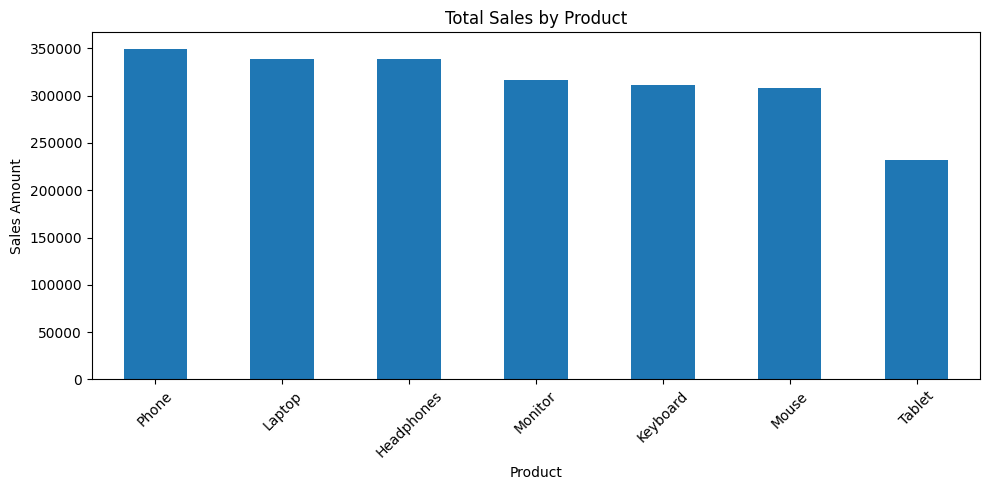

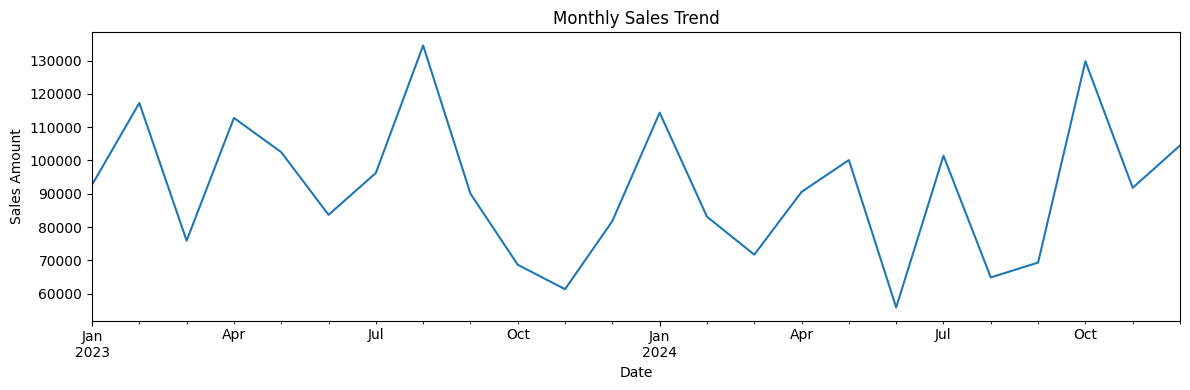

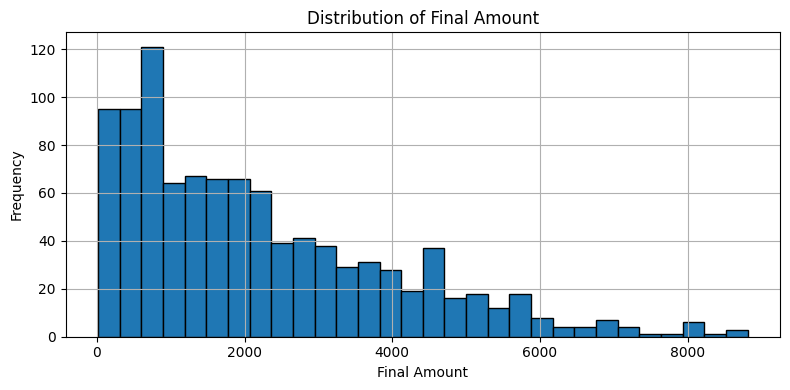

In [90]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Sales by product
product_sales = df.groupby('Product')['Final_Amount'].sum().sort_values(ascending=False)
product_sales.plot(kind='bar', figsize=(10, 5), title='Total Sales by Product')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Time series plot
monthly = df.groupby(df['Date'].dt.to_period('M'))['Final_Amount'].sum()
monthly.plot(kind='line', figsize=(12, 4), title='Monthly Sales Trend')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

# Distribution plot
df['Final_Amount'].hist(bins=30, figsize=(8, 4), edgecolor='black')
plt.title('Distribution of Final Amount')
plt.xlabel('Final Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 15. Real-World Analytics Projects

In [91]:
# Project 1: Customer Segmentation by Purchase Behavior
customer_summary = df.groupby('Customer_ID').agg({
    'Order_ID': 'count',
    'Final_Amount': ['sum', 'mean'],
    'Quantity': 'sum'
}).round(2)
customer_summary.columns = ['Num_Orders', 'Total_Spent', 'Avg_Order_Value', 'Total_Items']

# Segment customers
customer_summary['Segment'] = pd.cut(
    customer_summary['Total_Spent'],
    bins=[0, 1000, 5000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

print("Customer segments:")
print(customer_summary['Segment'].value_counts())
print()
print(customer_summary.head(10))

Customer segments:
Segment
Medium    315
High      163
Low       132
Name: count, dtype: int64

             Num_Orders  Total_Spent  Avg_Order_Value  Total_Items Segment
Customer_ID                                                               
1000                  1       576.12           576.12            1     Low
1002                  2      6978.55          3489.28           12    High
1003                  1      1038.39          1038.39            7  Medium
1004                  1      2061.09          2061.09            4  Medium
1006                  3      5111.62          1703.87            9    High
1007                  1      2279.04          2279.04            4  Medium
1010                  3     10303.84          3434.61           21    High
1011                  1       796.24           796.24            2     Low
1014                  2      4065.79          2032.90           10  Medium
1015                  2     12461.13          6230.56           18    High


In [92]:
# Project 2: Product Performance Analysis
product_perf = df.groupby('Product').agg({
    'Order_ID': 'count',
    'Quantity': 'sum',
    'Final_Amount': 'sum',
    'Discount': 'mean'
}).round(2)
product_perf.columns = ['Orders', 'Units_Sold', 'Revenue', 'Avg_Discount']
product_perf['Revenue_Per_Order'] = (product_perf['Revenue'] / product_perf['Orders']).round(2)

print("Product performance:")
print(product_perf.sort_values('Revenue', ascending=False))

Product performance:
            Orders  Units_Sold    Revenue  Avg_Discount  Revenue_Per_Order
Product                                                                   
Phone          153         732  349501.67         12.19            2284.32
Laptop         140         731  338962.51         12.09            2421.16
Headphones     160         817  338535.67         12.56            2115.85
Monitor        149         716  316607.97         12.43            2124.89
Keyboard       147         770  311656.63         11.93            2120.11
Mouse          136         702  307817.33         12.42            2263.36
Tablet         115         552  231742.13         12.05            2015.15


In [93]:
# Project 3: Regional Sales Analysis
regional_analysis = df.groupby('Region').agg({
    'Final_Amount': ['sum', 'mean'],
    'Order_ID': 'count',
    'Customer_ID': 'nunique'
}).round(2)
regional_analysis.columns = ['Total_Sales', 'Avg_Sale', 'Orders', 'Unique_Customers']
regional_analysis['Sales_Per_Customer'] = (
    regional_analysis['Total_Sales'] / regional_analysis['Unique_Customers']
).round(2)

print("Regional analysis:")
print(regional_analysis.sort_values('Total_Sales', ascending=False))

Regional analysis:
         Total_Sales  Avg_Sale  Orders  Unique_Customers  Sales_Per_Customer
Region                                                                      
North      471841.59   2215.22     213               183             2578.37
East       459885.23   2310.98     199               173             2658.30
West       426010.69   2218.81     192               174             2448.34
Central    405114.26   2066.91     196               176             2301.79
South      393215.35   2125.49     185               171             2299.50


## 16. Best Practices & Performance

In [94]:
# Memory optimization
print("=== Memory Optimization ===")
print(f"Original memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Optimize data types
df_opt = df.copy()
df_opt['Quantity'] = df_opt['Quantity'].astype('int8')
df_opt['Discount'] = df_opt['Discount'].astype('float32')
df_opt['Unit_Price'] = df_opt['Unit_Price'].astype('float32')

categorical_cols = ['Product', 'Category', 'Region', 'Salesperson', 'Payment_Method']
for col in categorical_cols:
    df_opt[col] = df_opt[col].astype('category')

print(f"Optimized memory: {df_opt.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()

# Vectorized operations (fast)
import time

# Bad: loop
start = time.time()
result_loop = []
for val in df['Unit_Price']:
    result_loop.append(val * 1.1)
loop_time = time.time() - start

# Good: vectorized
start = time.time()
result_vec = df['Unit_Price'] * 1.1
vec_time = time.time() - start

print(f"Loop time: {loop_time:.4f}s")
print(f"Vectorized time: {vec_time:.4f}s")
print(f"Speedup: {loop_time/vec_time:.1f}x faster")
print()

# Chaining operations
result = (df
    .query('Final_Amount > 1000')
    .groupby('Product')['Final_Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print("Method chaining example (top 5 products with sales > 1000):")
print(result)

=== Memory Optimization ===
Original memory: 0.49 MB
Optimized memory: 0.18 MB

Loop time: 0.0002s
Vectorized time: 0.0024s
Speedup: 0.1x faster

Method chaining example (top 5 products with sales > 1000):
Product
Phone         327855.60
Laptop        319763.28
Headphones    308458.05
Monitor       290766.08
Keyboard      287828.71
Name: Final_Amount, dtype: float64
